In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS
from linearmodels import PanelOLS
import rasterio
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import gaussian_filter
import statsmodels.api as sm

In [ ]:
# 手动输入每个栅格文件的年份和文件路径
years = [2000, 2010, 2020]
year_road = [2000, 2009, 2020]
file_paths = {
    "DEM": r"H:\7.Eco_parameter\Drivers\Driver_data\DEM\Dem_hunan.tif",
    "highway": [r"H:\7.Eco_parameter\Drivers\Driver_data\Distance to highway\highway_" + str(yr) + ".tif" for yr in year_road],
    "national_highway": [r"H:\7.Eco_parameter\Drivers\Driver_data\distance to national highway\national_highway_" + str(yr) + ".tif" for yr in year_road],
    "railroad": [r"H:\7.Eco_parameter\Drivers\Driver_data\Distance to railroad\railroad_" + str(yr) + ".tif" for yr in year_road],
    "NDVI": [r"H:\7.Eco_parameter\Drivers\Driver_data\NDVI\NDVI_" + str(yr) + ".tif" for yr in years],
    "NTL": [r"H:\7.Eco_parameter\Drivers\Driver_data\Night time light\NTL_" + str(yr) + ".tif" for yr in years],
    "POP": [r"H:\7.Eco_parameter\Drivers\Driver_data\Pop\population_" + str(yr) + ".tif" for yr in years],
    "Precipitation": [r"H:\7.Eco_parameter\Drivers\Driver_data\Precipitation\precipitation_" + str(yr) + ".tif" for yr in years],
    "Temperature": [r"H:\7.Eco_parameter\Drivers\Driver_data\Temperature\temperature_" + str(yr) + ".tif" for yr in years],
    "Carbon_storage": [r"H:\7.Eco_parameter\Drivers\Driver_data\Revised_carbon_storage\revised_carbon_storage_1km_" + str(yr) + ".tif" for yr in years],
    "Land_cover": [r"H:\7.Eco_parameter\Flus\Result\LC_" + str(yr) + "_uc.tif" for yr in years]
}

# 初始化空列表来存储每年的数据
data_list = []

# 逐年读取栅格数据
for i, year in enumerate(years):
    year_data = {"Year": year}
    for var_name, paths in file_paths.items():
        # 对于单一文件，如 DEM
        if isinstance(paths, str):
            with rasterio.open(paths) as src:
                arr = src.read(1)
                if var_name == "Land_cover":
                    arr = arr.astype(float)
                    mask_valid = (arr >= 1) & (arr <= 6)
                    arr[~mask_valid] = np.nan
                year_data[var_name] = arr.flatten()
        # 对于每年不同文件的变量
        else:
            with rasterio.open(paths[i]) as src:
                arr = src.read(1)
                if var_name == "Land_cover":
                    arr = arr.astype(float)
                    mask_valid = (arr >= 1) & (arr <= 6)
                    arr[~mask_valid] = np.nan
                year_data[var_name] = arr.flatten()
    
    # 将年数据转换为 DataFrame
    year_df = pd.DataFrame(year_data)
    year_df["ID"] = np.arange(len(year_df))  # 分配唯一 ID
    data_list.append(year_df)

# 合并所有年份的数据
panel_data = pd.concat(data_list)

# 设置面板数据格式
panel_data = panel_data.set_index(["ID", "Year"])
panel_data = panel_data.rename(columns={"highway": "DH", "national_highway": "DNH", "railroad": "DR"})
panel_data = panel_data.dropna()

In [34]:
panel_data = panel_data.rename(columns={"highway": "DH", "national_highway": "DNH", "railroad": "DR","Pop": "POP"})
panel_data = panel_data.dropna()
panel_data

,,DEM,DH,DNH,DR,NDVI,NTL,POP,Precipitation,Temperature,Carbon_storage,Land_cover
ID,Year,,,,,,,,,,,
226,2000,1705.023193,2.626739,0.966960,0.688666,0.830828,0,0.693194,1464.400024,11.158334,0.000000,6.0
227,2000,1683.445435,2.618082,0.959303,0.683650,0.847182,0,0.450440,1467.699951,10.950000,0.000000,6.0
228,2000,1540.035645,2.609426,0.951655,0.678667,0.857280,0,0.907975,1454.599976,11.375000,0.000000,2.0
229,2000,1600.666992,2.600774,0.944055,0.673854,0.857280,0,0.798520,1454.300049,11.291667,0.000000,2.0
230,2000,1565.900635,2.592123,0.936455,0.669041,0.843150,0,0.553636,0.000000,0.000000,0.000000,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
371799,2020,1282.958252,0.707294,0.094248,0.182270,0.812594,1,0.151090,1819.776245,15.916667,11.755335,2.0
371800,2020,1153.474854,0.716276,0.101355,0.191253,0.845791,0,0.125934,0.000000,0.000000,0.000000,2.0
372405,2020,1093.170410,0.671256,0.073603,0.146337,0.800582,0,0.138222,1802.177368,16.041666,12.799332,2.0


In [36]:
# 提取2000年的driver数据
driver_2000 = panel_data[panel_data.index.get_level_values('Year') == 2000]

# 选择用于共线性检验的自变量
X = driver_2000[["DEM", "DH", "DNH", "DR", "NDVI", "NTL", "POP"]]

# 计算各变量的VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 需要去除缺失值
X_no_na = X.dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_no_na.columns
vif_data["VIF"] = [variance_inflation_factor(X_no_na.values, i) for i in range(X_no_na.shape[1])]

print(vif_data)

  Variable       VIF
0      DEM  3.630068
1       DH  3.759885
2      DNH  2.427072
3       DR  3.030521
4     NDVI  6.894289
5      NTL  1.500840
6      POP  1.439231


In [38]:
# 提取2010年的driver数据
driver_2010 = panel_data[panel_data.index.get_level_values('Year') == 2010]

# 选择用于共线性检验的自变量
X = driver_2010[["DEM", "DH", "DNH", "DR", "NDVI", "NTL", "POP"]]

# 计算各变量的VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 需要去除缺失值
X_no_na = X.dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_no_na.columns
vif_data["VIF"] = [variance_inflation_factor(X_no_na.values, i) for i in range(X_no_na.shape[1])]

print(vif_data)

  Variable       VIF
0      DEM  3.615190
1       DH  3.739010
2      DNH  2.787563
3       DR  3.698702
4     NDVI  5.086949
5      NTL  1.443896
6      POP  1.344779


In [37]:
# 提取2000年的driver数据
driver_2020 = panel_data[panel_data.index.get_level_values('Year') == 2020]

# 选择用于共线性检验的自变量
X = driver_2020[["DEM", "DH", "DNH", "DR", "NDVI", "NTL", "POP"]]

# 计算各变量的VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 需要去除缺失值
X_no_na = X.dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_no_na.columns
vif_data["VIF"] = [variance_inflation_factor(X_no_na.values, i) for i in range(X_no_na.shape[1])]

print(vif_data)

  Variable       VIF
0      DEM  3.318174
1       DH  4.130520
2      DNH  2.858807
3       DR  3.604696
4     NDVI  5.099949
5      NTL  1.488243
6      POP  1.280188


In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

# 存储每一年的结果
results_per_year = {}
years = [2000, 2010, 2020]
for year in years:  
    # 筛选该年份的数据
    yearly_data = panel_data[panel_data.index.get_level_values('Year') == year]
    # X = yearly_data[["DEM", "DH", "DNH", "DR", "NDVI", "NTL", "Pop", "Precipitation", "Temperature","Land_cover"]]
    X = yearly_data[["DEM", "DH", "DNH", "DR", "NDVI",'POP',"NTL"]]
    y = yearly_data["Carbon_storage"]
    
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 初始化随机森林回归器
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    # 拟合模型
    rf.fit(X_train, y_train)
    
    # 预测并评估
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # 显示变量重要性
    importance = rf.feature_importances_
    feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importance}).sort_values(by='Importance', ascending=False)
    
    # 将结果存储到字典中
    results_per_year[year] = {
        "R-squared": r2,
        "RMSE": rmse,
        "Feature Importance": feature_importance
    }
    
    print(f"Year: {year}")
    print(f"R-squared: {r2}")
    print(f"RMSE: {rmse}")
    print("Feature Importance:")
    print(feature_importance)
    print("\n" + "="*40 + "\n")

# 所有年份的结果已存储在 results_per_year 字典中

Year: 2000
R-squared: 0.8144669068608743
RMSE: 1.2376582124584419
Feature Importance:
  Feature  Importance
4    NDVI    0.472838
5     POP    0.149571
0     DEM    0.124437
1      DH    0.111504
3      DR    0.070654
2     DNH    0.062178
6     NTL    0.008819


Year: 2010
R-squared: 0.7906474730350569
RMSE: 1.3895753995705382
Feature Importance:
  Feature  Importance
5     POP    0.467036
0     DEM    0.178061
4    NDVI    0.132808
3      DR    0.070305
1      DH    0.063889
2     DNH    0.058072
6     NTL    0.029829


Year: 2020
R-squared: 0.7991498674305966
RMSE: 1.359948917032308
Feature Importance:
  Feature  Importance
4    NDVI    0.562056
0     DEM    0.170808
5     POP    0.104096
1      DH    0.047227
2     DNH    0.045996
3      DR    0.045294
6     NTL    0.024522




In [43]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# 假设 panel_data 已经加载且格式正确
# 准备数据的年份列表
years = [2000, 2010, 2020]

# 用于存储每个年份的模型、SHAP 值和抽样的测试数据
models = {}
shap_values_dict = {}
X_test_sampled_dict = {}

# 对每个年份的数据分别训练模型
for year in years:
    # 筛选该年份的数据
    yearly_data = panel_data[panel_data.index.get_level_values('Year') == year]
    # X = yearly_data[["DEM", "DH", "DNH", "DR", "NDVI", "NTL", "Pop", "Precipitation", "Temperature"]]
    X = yearly_data[["DEM", "DH", "DNH", "DR", "NDVI", "NTL","POP"]]
    y = yearly_data["Carbon_storage"]
    
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 初始化随机森林模型
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    # 训练模型
    rf.fit(X_train, y_train)
    
    # 将模型存储在字典中
    models[f"rf_{year}"] = rf
    
    # 抽样 500 个测试样本
    X_test_sampled = X_test.sample(500, random_state=42)
    X_test_sampled_dict[f"X_test_sampled_{year}"] = X_test_sampled  # 将抽样的测试数据存储在字典中
    
    # 创建 SHAP 分析器并计算 SHAP 值
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test_sampled)  # 使用抽样测试数据计算 SHAP 值
    shap_values_dict[f"shap_values_{year}"] = shap_values  # 将 SHAP 值存储在字典中
    
    # 打印每个年份的模型训练信息
    print(f"Year {year} model trained as rf_{year}")

# 检查字典是否保存了每年抽样的测试数据和 SHAP 值
print("Models:", models.keys())
print("SHAP Values:", shap_values_dict.keys())
print("Sampled Test Data:", X_test_sampled_dict.keys())

Year 2000 model trained as rf_2000
Year 2010 model trained as rf_2010
Year 2020 model trained as rf_2020
Models: dict_keys(['rf_2000', 'rf_2010', 'rf_2020'])
SHAP Values: dict_keys(['shap_values_2000', 'shap_values_2010', 'shap_values_2020'])
Sampled Test Data: dict_keys(['X_test_sampled_2000', 'X_test_sampled_2010', 'X_test_sampled_2020'])


d:\Anaconda\envs\pytorch_environment\Lib\site-packages\shap\plots\_beeswarm.py:950: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


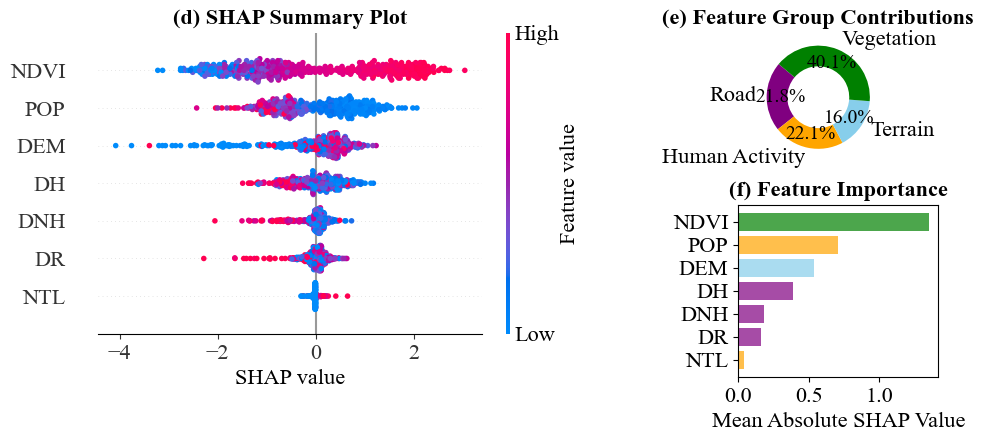

d:\Anaconda\envs\pytorch_environment\Lib\site-packages\shap\plots\_beeswarm.py:950: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


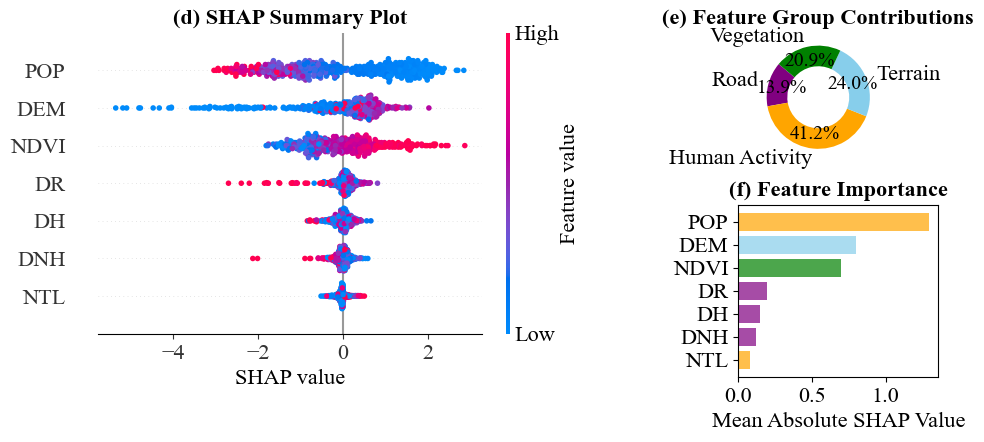

d:\Anaconda\envs\pytorch_environment\Lib\site-packages\shap\plots\_beeswarm.py:950: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


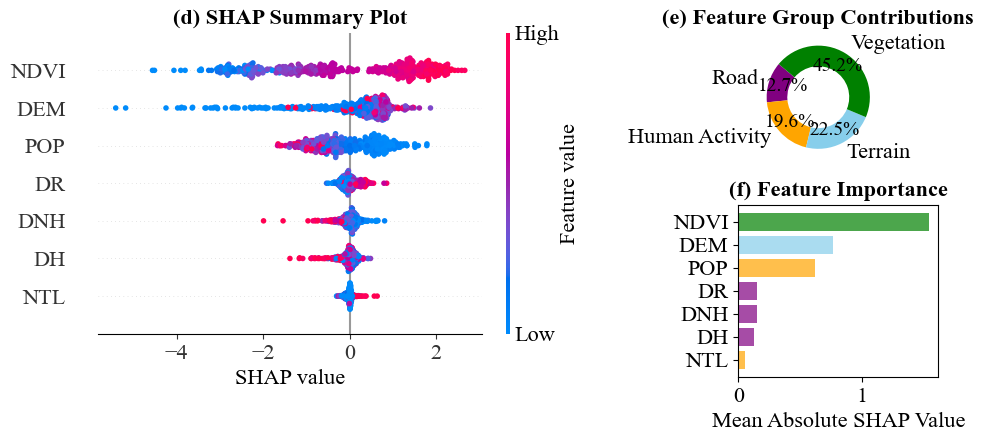

In [51]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 设置全局字体为 Times New Roman，大小为 16
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 16
})

# 定义特征分组和颜色
feature_groups = {
    'Road': ['DH', 'DNH', 'DR'],
    'Human Activity': ['POP', 'NTL'],
    # 'Climate': ['Precipitation', 'Temperature'],
    'Terrain': ['DEM'],
    'Vegetation': ['NDVI']
}

group_colors = {
    'Vegetation': 'green',
    'Human Activity': 'orange',
    # 'Climate': 'green',
    'Terrain': 'skyblue',
    'Road': 'purple'
}

# 年份列表
years = [2000, 2010, 2020]

# 循环遍历每一年，绘制各年图表
for year in years:
    # 获取该年的 SHAP 值和抽样的 X_test 数据
    shap_values = shap_values_dict[f"shap_values_{year}"]
    X_test_sampled = X_test_sampled_dict[f"X_test_sampled_{year}"]

    # 计算每个特征的平均 SHAP 值绝对值（特征重要性）
    mean_abs_shap_values = np.abs(shap_values).mean(axis=0)
    feature_importance = pd.DataFrame({
        "Feature": X_test_sampled.columns,
        "Mean Abs SHAP Value": mean_abs_shap_values
    })

    # 计算每个特征组的贡献值总和
    group_contributions = {}
    for group, features in feature_groups.items():
        group_contributions[group] = feature_importance[feature_importance["Feature"].isin(features)]["Mean Abs SHAP Value"].sum()

    # 获取组标签和贡献值
    group_labels = list(group_contributions.keys())
    group_contrib_values = list(group_contributions.values())
    colors = [group_colors[group] for group in group_labels]

    # 创建一个大的绘图区域
    fig = plt.figure(figsize=(24, 14))  # 增大整体图的尺寸

    # 1. 绘制 SHAP Summary Plot
    ax1 = fig.add_axes([0.05, 0.2, 0.6, 0.7])  # 设置 SHAP Summary Plot 的位置和大小
    shap.summary_plot(shap_values, X_test_sampled, plot_type="dot", color=plt.get_cmap("cool"), show=False)

    # 增大 X 轴标签和 colorbar 字体
    ax1.set_xlabel("SHAP value", fontsize=16)
    colorbar = plt.gcf().axes[-1]  # 获取 colorbar
    colorbar.tick_params(labelsize=16)
    colorbar.set_ylabel("Feature value", fontsize=16)
    
    ax1.set_title("(d) SHAP Summary Plot", fontsize=16, fontweight='bold')
    ax1.tick_params(labelsize=16)  # 增大 SHAP 图中的标签字体

    # 2. 绘制放大后的环形图，显示各特征组的贡献值比例
    ax2 = fig.add_axes([0.8, 0.6, 0.3, 0.3])  # 调整环形图位置和大小
    wedges, texts, autotexts = ax2.pie(
        group_contrib_values, labels=group_labels, autopct='%1.1f%%', colors=colors, startangle=140,
        wedgeprops=dict(width=0.4), pctdistance=0.72,labeldistance=1.2  # 使用 pctdistance 将百分比移到环外
    )
    
    # 设置标注的字体大小和外观
    for autotext in autotexts:
        autotext.set_fontsize(14)
    
    ax2.set_aspect("equal")  # 保持环形比例
    ax2.set_title("(e) Feature Group Contributions", fontsize=16, fontweight='bold')

    # 3. 绘制特征重要性柱状图并使用组颜色
    feature_importance = feature_importance.sort_values(by="Mean Abs SHAP Value", ascending=True)
    bar_colors = []
    for feature in feature_importance["Feature"]:
        for group, features in feature_groups.items():
            if feature in features:
                bar_colors.append(group_colors[group])

    ax3 = fig.add_axes([0.85, 0.1, 0.25, 0.4])  # 调整柱状图的位置和大小
    ax3.barh(feature_importance["Feature"], feature_importance["Mean Abs SHAP Value"], color=bar_colors, alpha=0.7)
    ax3.set_xlabel("Mean Absolute SHAP Value", fontsize=16)
    ax3.set_title("(f) Feature Importance", fontsize=16, fontweight='bold')
    ax3.tick_params(labelsize=16)  # 增大柱状图标签字体

    # 显示图表
    # plt.savefig(fr"H:\7.Eco_parameter\Figures\修正后的驱动因子分析\SHAP_summary_plot_{year}.png", dpi=600, bbox_inches="tight")
    plt.show()
